In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

In [2]:
# pip install kmodes

In [3]:
# import data

df_student = pd.read_csv("dataset/student_math_clean.csv")
df_student.head()


,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,GP,F,18,Urban,Greater than 3,Apart,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,GP,F,17,Urban,Greater than 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,GP,F,15,Urban,Less than or equal to 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,GP,F,15,Urban,Greater than 3,Living together,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,GP,F,16,Urban,Greater than 3,Living together,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df_student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             395 non-null    int64 
 1   school                 395 non-null    object
 2   sex                    395 non-null    object
 3   age                    395 non-null    int64 
 4   address_type           395 non-null    object
 5   family_size            395 non-null    object
 6   parent_status          395 non-null    object
 7   mother_education       395 non-null    object
 8   father_education       395 non-null    object
 9   mother_job             395 non-null    object
 10  father_job             395 non-null    object
 11  school_choice_reason   395 non-null    object
 12  guardian               395 non-null    object
 13  travel_time            395 non-null    object
 14  study_time             395 non-null    object
 15  class_failures         

In [5]:
df_student.columns

Index(['student_id', 'school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason', 'guardian', 'travel_time',
       'study_time', 'class_failures', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship', 'family_relationship',
       'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
       'absences', 'grade_1', 'grade_2', 'final_grade'],
      dtype='object')

In [6]:
df_student2 = df_student.copy()

In [7]:
cols_toencode = ['school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason','guardian', 'travel_time',
       'study_time', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship']

for col in cols_toencode:

    # # label encoding
    # le = LabelEncoder()
    # df_student2[col] = le.fit_transform(df_student2[col])
    # print(f"Label Encoding {col}: {le.classes_}")

    print(col, df_student2[col].nunique())
    # pakai one-hot encoding untuk kolom dengan jumlah kategori yang sedikit
    if df_student2[col].nunique() <= 4:
        df_student2 = pd.get_dummies(df_student2, columns=[col], prefix=[col], drop_first=True, dtype=int)
    else:
        le = LabelEncoder()
        df_student2[col] = le.fit_transform(df_student2[col])
        print(f"Label Encoding {col}: {le.classes_}")

df_student2.head()

school 2
sex 2
age 8
Label Encoding age: [15 16 17 18 19 20 21 22]
address_type 2
family_size 2
parent_status 2
mother_education 5
Label Encoding mother_education: ['5th to 9th grade' 'higher education' 'none'
 'primary education (4th grade)' 'secondary education']
father_education 5
Label Encoding father_education: ['5th to 9th grade' 'higher education' 'none'
 'primary education (4th grade)' 'secondary education']
mother_job 5
Label Encoding mother_job: ['at_home' 'health' 'other' 'services' 'teacher']
father_job 5
Label Encoding father_job: ['at_home' 'health' 'other' 'services' 'teacher']
school_choice_reason 4
guardian 3
travel_time 4
study_time 4
school_support 2
family_support 2
extra_paid_classes 2
activities 2
nursery_school 2
higher_ed 2
internet_access 2
romantic_relationship 2


,student_id,age,mother_education,father_education,mother_job,father_job,class_failures,family_relationship,free_time,social,...,study_time_<2 hours,study_time_>10 hours,school_support_yes,family_support_yes,extra_paid_classes_yes,activities_yes,nursery_school_yes,higher_ed_yes,internet_access_yes,romantic_relationship_yes
0,1,3,1,1,0,4,0,4,3,4,...,0,0,1,0,0,0,1,1,0,0
1,2,2,3,3,0,2,0,5,3,3,...,0,0,0,1,0,0,0,1,1,0
2,3,0,3,3,0,2,3,4,3,2,...,0,0,1,0,1,0,1,1,1,0
3,4,0,1,0,1,3,0,3,2,2,...,0,0,0,1,1,1,1,1,1,1
4,5,1,4,4,2,2,0,4,3,2,...,0,0,0,1,1,0,1,1,0,0


In [8]:
df_student2.columns

Index(['student_id', 'age', 'mother_education', 'father_education',
       'mother_job', 'father_job', 'class_failures', 'family_relationship',
       'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
       'absences', 'grade_1', 'grade_2', 'final_grade', 'school_MS', 'sex_M',
       'address_type_Urban', 'family_size_Less than or equal to 3',
       'parent_status_Living together', 'school_choice_reason_home',
       'school_choice_reason_other', 'school_choice_reason_reputation',
       'guardian_mother', 'guardian_other', 'travel_time_30 min. to 1 hour',
       'travel_time_<15 min.', 'travel_time_>1 hour',
       'study_time_5 to 10 hours', 'study_time_<2 hours',
       'study_time_>10 hours', 'school_support_yes', 'family_support_yes',
       'extra_paid_classes_yes', 'activities_yes', 'nursery_school_yes',
       'higher_ed_yes', 'internet_access_yes', 'romantic_relationship_yes'],
      dtype='object')

In [9]:
df_student2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 41 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   student_id                           395 non-null    int64
 1   age                                  395 non-null    int64
 2   mother_education                     395 non-null    int64
 3   father_education                     395 non-null    int64
 4   mother_job                           395 non-null    int64
 5   father_job                           395 non-null    int64
 6   class_failures                       395 non-null    int64
 7   family_relationship                  395 non-null    int64
 8   free_time                            395 non-null    int64
 9   social                               395 non-null    int64
 10  weekday_alcohol                      395 non-null    int64
 11  weekend_alcohol                      395 non-null    int64

In [10]:
# data unik seperti student_id tidak perlu dimasukkan ke clustering
df_student2 = df_student2.drop(columns=['student_id'])

In [11]:
X = df_student2
X.head()


,age,mother_education,father_education,mother_job,father_job,class_failures,family_relationship,free_time,social,weekday_alcohol,...,study_time_<2 hours,study_time_>10 hours,school_support_yes,family_support_yes,extra_paid_classes_yes,activities_yes,nursery_school_yes,higher_ed_yes,internet_access_yes,romantic_relationship_yes
0,3,1,1,0,4,0,4,3,4,1,...,0,0,1,0,0,0,1,1,0,0
1,2,3,3,0,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,0,3,3,0,2,3,4,3,2,2,...,0,0,1,0,1,0,1,1,1,0
3,0,1,0,1,3,0,3,2,2,1,...,0,0,0,1,1,1,1,1,1,1
4,1,4,4,2,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


In [12]:
# scaler
scaler = StandardScaler()
df_student_scaled = scaler.fit_transform(X)

In [13]:
# PCA
model_pca = PCA(random_state=42)
X_pca = model_pca.fit_transform(df_student_scaled)

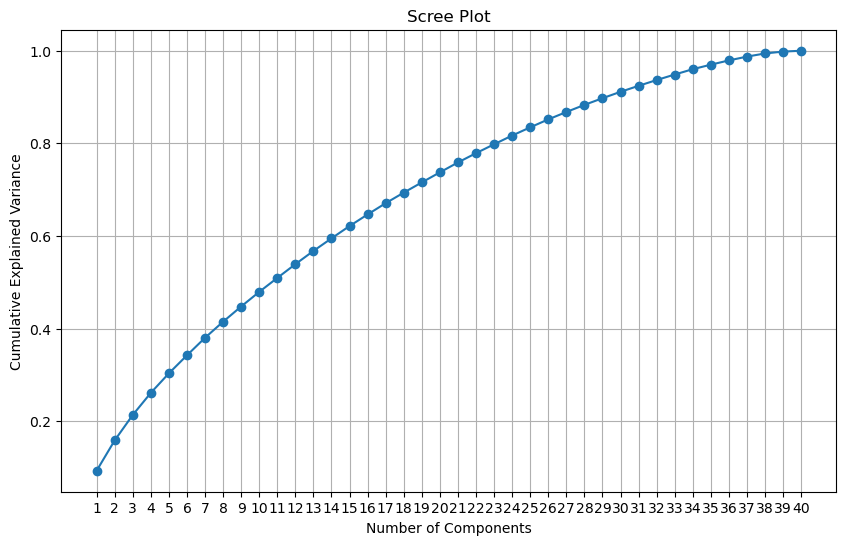

In [14]:
# pemilihan jumlah komponen PCA
# scree plot menggunakan explained variance
explained_variance = model_pca.explained_variance_ratio_
explained_variance_cumsum = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(explained_variance_cumsum, marker='o')

plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(ticks=np.arange(len(explained_variance_cumsum)), labels=np.arange(1, len(explained_variance_cumsum)+1))
plt.grid()
plt.show()

In [15]:
# ambil 18 komponen (70% variance explained)
model_pca_18 = PCA(n_components=18, random_state=42)
X_pca_18 = model_pca_18.fit_transform(df_student_scaled)

In [16]:
X_pca_18.shape

(395, 18)

In [17]:
# clustering dengan DBSCAN
# DBSCAN tidak perlu menentukan jumlah cluster di awal

model_dbscan = DBSCAN(eps=5, min_samples=5)

# buat kolom cluster
df_student2['cluster'] = model_dbscan.fit_predict(X_pca_18)

In [18]:
df_student2.head()

,age,mother_education,father_education,mother_job,father_job,class_failures,family_relationship,free_time,social,weekday_alcohol,...,study_time_>10 hours,school_support_yes,family_support_yes,extra_paid_classes_yes,activities_yes,nursery_school_yes,higher_ed_yes,internet_access_yes,romantic_relationship_yes,cluster
0,3,1,1,0,4,0,4,3,4,1,...,0,1,0,0,0,1,1,0,0,0
1,2,3,3,0,2,0,5,3,3,1,...,0,0,1,0,0,0,1,1,0,0
2,0,3,3,0,2,3,4,3,2,2,...,0,1,0,1,0,1,1,1,0,0
3,0,1,0,1,3,0,3,2,2,1,...,0,0,1,1,1,1,1,1,1,0
4,1,4,4,2,2,0,4,3,2,1,...,0,0,1,1,0,1,1,0,0,0


In [19]:
df_student2['cluster'].value_counts()

cluster
 0    346
-1     49
Name: count, dtype: int64

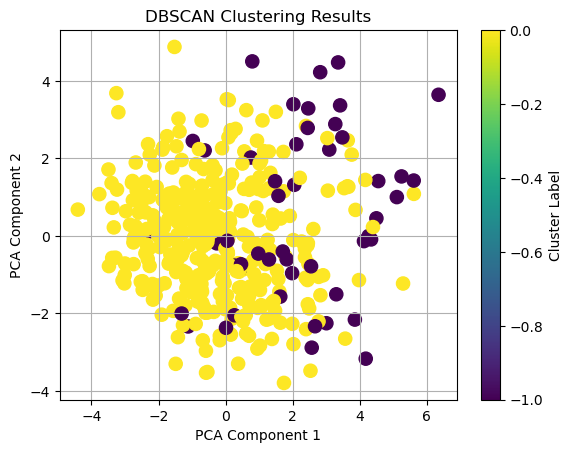

In [20]:
# optional - visualisasi hasil clustering
plt.figure()
plt.scatter(X_pca_18[:, 0], X_pca_18[:, 1], c=df_student2['cluster'], cmap='viridis', s=90)
plt.title('DBSCAN Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()

DBScan sepertinya tidak berhasil mencari cluster data berdasarkan density, kita bisa coba:

- K-Mode, biasanya lebih cocok untuk data yang sifatnya kategorikal
- K-Prototype, cocok untuk data mixed numerical dan kategorikal

In [21]:
model_kmodes = KModes(n_clusters=3, init='Huang', n_init=5, verbose=1)
clusters = model_kmodes.fit_predict(df_student2)
df_student2['kmodes_cluster'] = clusters
df_student2['kmodes_cluster'].value_counts()

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 123, cost: 5608.0
Run 1, iteration: 2/100, moves: 51, cost: 5595.0
Run 1, iteration: 3/100, moves: 13, cost: 5595.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 150, cost: 5655.0
Run 2, iteration: 2/100, moves: 32, cost: 5655.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 154, cost: 5644.0
Run 3, iteration: 2/100, moves: 88, cost: 5620.0
Run 3, iteration: 3/100, moves: 35, cost: 5603.0
Run 3, iteration: 4/100, moves: 4, cost: 5603.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 126, cost: 5724.0
Run 4, iteration: 2/100, moves: 15, cost: 5724.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 139, cost: 5629.0
Run 5, i

kmodes_cluster
0    153
2    124
1    118
Name: count, dtype: int64

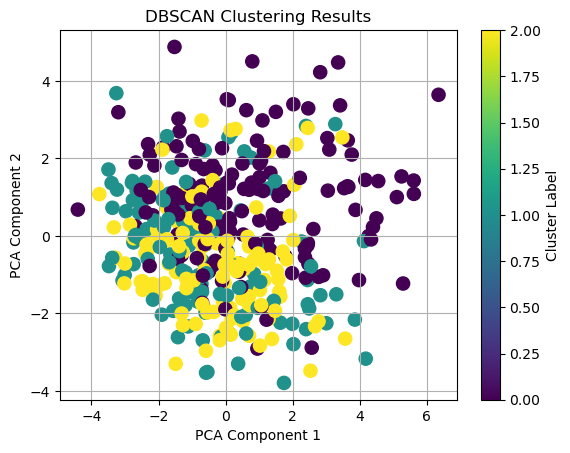

In [23]:
# optional - visualisasi hasil clustering
plt.figure()
plt.scatter(X_pca_18[:, 0], X_pca_18[:, 1], c=df_student2['kmodes_cluster'], cmap='viridis', s=90)
plt.title('DBSCAN Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.grid()
plt.show()